# Projeto Final: Steelproof
## Etapa 1: Plano de Trabalho

Previsão da temperatura final do aço no refino em panela para redução do consumo de energia.

Este notebook apresenta o planejamento da solução. Ele cobre a leitura do problema sob a ótica de negócio, o diagnóstico dos dados fornecidos, a análise exploratória inicial, os algoritmos candidatos, os indicadores de desempenho, o desenho experimental, o cronograma de atividades e os stakeholders envolvidos. Ao final estão as perguntas de esclarecimento para a chamada com o líder de equipe e o plano geral de resolução.

---
## 1. Identificação do problema de negócio

### 1.1 O setor e a etapa do processo

A Steelproof opera uma aciaria e o caso trata da etapa de metalurgia secundária, também chamada de refino em panela ou forno-panela. Nessa etapa o aço líquido, já vazado do forno primário, recebe o acabamento antes de seguir para o lingotamento contínuo.

O ciclo de trabalho na panela alterna quatro operações: aquecimento por eletrodos de grafite, dessulfuração, adição de ligas metálicas em forma de lingote ou arame, e homogeneização com purga de gás inerte. Entre essas operações o operador mede a temperatura e coleta amostra para análise química. O ciclo se repete até que a composição e a temperatura fiquem dentro da especificação exigida pelo lingotamento.

Na siderurgia a energia elétrica responde por parcela relevante do custo de conversão do aço, e o forno-panela concentra boa parte desse consumo dentro da metalurgia secundária. Além da energia, cada ciclo de aquecimento consome eletrodo de grafite, que é um insumo caro e de reposição periódica.

### 1.2 O problema

O operador não sabe de antemão qual será a temperatura resultante de um ciclo de aquecimento. Sem essa previsão, a prática segura é aquecer com margem, medir de novo e repetir se necessário. Isso produz três perdas:

Consumo de energia acima do necessário, porque a margem de segurança é aplicada em todos os lotes e não apenas nos que precisam.

Desgaste adicional de eletrodo, proporcional ao tempo de arco aplicado.

Ocupação prolongada da panela, o que reduz a vazão da aciaria e pode atrasar o lingotamento.

### 1.3 A solução proposta e o valor gerado

Construir um modelo que preveja a temperatura final do lote a partir das variáveis já registradas no processo. Com essa previsão disponível antes do aquecimento, o operador consegue dimensionar a energia a aplicar em vez de trabalhar por tentativa.

O retorno aparece em quatro frentes. Redução direta do custo de energia elétrica por tonelada de aço. Menor consumo de eletrodo de grafite. Aumento da vazão da aciaria pela redução do tempo médio de panela. Redução das emissões associadas ao consumo elétrico, o que atende à agenda de sustentabilidade citada no contexto do caso.

Como o volume de produção é alto e o processo se repete milhares de vezes por ano, mesmo uma economia percentual pequena por lote tem efeito relevante no resultado anual.

---
## 2. Descrição dos dados

Os dados vêm de sete arquivos que registram diferentes etapas do tratamento. Todos se conectam pela coluna `key`, que identifica o lote de aço. Arquivos como `data_arc_en.csv` e `data_temp_en.csv` trazem várias linhas por lote, uma para cada iteração do processo, enquanto os demais já vêm com uma linha por lote.

Os nomes de colunas e features criadas ao longo do notebook são mantidos sem acentuação para evitar problemas de codificação entre ambientes.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
try:
    sns.set_theme(style='whitegrid')
except AttributeError:
    sns.set(style='whitegrid')
    
CAMINHOS = ['/datasets/', './']
PASTA = next((p for p in CAMINHOS if os.path.exists(p + 'data_temp_en.csv')), None)

if PASTA is None:
    raise FileNotFoundError('Arquivos não encontrados nos caminhos testados.')

print('Lendo os arquivos de:', PASTA)

arc       = pd.read_csv(PASTA + 'data_arc_en.csv')
bulk      = pd.read_csv(PASTA + 'data_bulk_en.csv')
bulk_time = pd.read_csv(PASTA + 'data_bulk_time_en.csv')
gas       = pd.read_csv(PASTA + 'data_gas_en.csv')
temp      = pd.read_csv(PASTA + 'data_temp_en.csv')
wire      = pd.read_csv(PASTA + 'data_wire_en.csv')
wire_time = pd.read_csv(PASTA + 'data_wire_time_en.csv')

Lendo os arquivos de: /datasets/


### 2.1 Dimensões e cobertura de lotes

O primeiro passo é verificar o tamanho de cada arquivo e quantos lotes distintos ele cobre.

In [2]:
dados = {
    'data_arc_en'       : arc,
    'data_bulk_en'      : bulk,
    'data_bulk_time_en' : bulk_time,
    'data_gas_en'       : gas,
    'data_temp_en'      : temp,
    'data_wire_en'      : wire,
    'data_wire_time_en' : wire_time,
}

resumo = pd.DataFrame([
    {
        'arquivo'    : nome,
        'linhas'     : df.shape[0],
        'colunas'    : df.shape[1],
        'lotes'      : df['key'].nunique(),
        'linhas_por_lote': round(df.shape[0] / df['key'].nunique(), 2),
        'duplicadas' : df.duplicated().sum(),
        'nulos'      : df.isna().sum().sum(),
    }
    for nome, df in dados.items()
])

resumo

,arquivo,linhas,colunas,lotes,linhas_por_lote,duplicadas,nulos
0,data_arc_en,14876,5,3214,4.63,0,0
1,data_bulk_en,3129,16,3129,1.00,0,35776
2,data_bulk_time_en,3129,16,3129,1.00,0,35776
3,data_gas_en,3239,2,3239,1.00,0,0
4,data_temp_en,15907,3,3216,4.95,0,2901
5,data_wire_en,3081,10,3081,1.00,0,23385
6,data_wire_time_en,3081,10,3081,1.00,0,23385


A tabela acima mostra o tamanho de cada fonte isoladamente. Falta saber o quanto elas se sobrepõem, já que a decisão sobre como uni-las depende disso.

In [3]:
conjuntos = {nome: set(df['key']) for nome, df in dados.items()}
todos = set.union(*conjuntos.values())
comuns = set.intersection(*conjuntos.values())

print('Lotes distintos em ao menos um arquivo:', len(todos))
print('Lotes presentes em todos os sete arquivos:', len(comuns))
print()
for nome, s_ in conjuntos.items():
    print(f'{nome:20s} cobre {len(s_):5d} lotes | ausentes em relação ao total: {len(todos - s_):4d}')

Lotes distintos em ao menos um arquivo: 3241
Lotes presentes em todos os sete arquivos: 3022

data_arc_en          cobre  3214 lotes | ausentes em relação ao total:   27
data_bulk_en         cobre  3129 lotes | ausentes em relação ao total:  112
data_bulk_time_en    cobre  3129 lotes | ausentes em relação ao total:  112
data_gas_en          cobre  3239 lotes | ausentes em relação ao total:    2
data_temp_en         cobre  3216 lotes | ausentes em relação ao total:   25
data_wire_en         cobre  3081 lotes | ausentes em relação ao total:  160
data_wire_time_en    cobre  3081 lotes | ausentes em relação ao total:  160


A tabela mostra dois grupos distintos. `data_arc_en` e `data_temp_en` têm várias linhas por lote, o que confirma o caráter iterativo do tratamento. Os outros cinco arquivos têm exatamente uma linha por lote. Nenhum arquivo apresenta linhas duplicadas, o que elimina uma preocupação comum de qualidade.

A cobertura de lotes varia entre as fontes, e a interseção completa é menor que qualquer arquivo isolado. Isso significa que exigir presença simultânea nas sete fontes reduziria a base de forma desnecessária, já que a ausência em `data_bulk_en` ou `data_wire_en` indica material não utilizado e não lote inválido.

O critério de junção adotado reflete essa distinção: junção interna apenas entre temperatura e arco, que são obrigatórias para definir alvo e energia, e junção à esquerda para as demais fontes, cuja ausência é preenchida com zero.

### 2.2 Estrutura de cada arquivo

In [4]:
for nome, df in dados.items():
    print('=' * 70)
    print(nome, '| shape:', df.shape)
    print('-' * 70)
    print(df.dtypes.to_string())
    print()

data_arc_en | shape: (14876, 5)
----------------------------------------------------------------------
key                    int64
Arc heating start     object
Arc heating end       object
Active power         float64
Reactive power       float64

data_bulk_en | shape: (3129, 16)
----------------------------------------------------------------------
key          int64
Bulk 1     float64
Bulk 2     float64
Bulk 3     float64
Bulk 4     float64
Bulk 5     float64
Bulk 6     float64
Bulk 7     float64
Bulk 8     float64
Bulk 9     float64
Bulk 10    float64
Bulk 11    float64
Bulk 12    float64
Bulk 13    float64
Bulk 14    float64
Bulk 15    float64

data_bulk_time_en | shape: (3129, 16)
----------------------------------------------------------------------
key         int64
Bulk 1     object
Bulk 2     object
Bulk 3     object
Bulk 4     object
Bulk 5     object
Bulk 6     object
Bulk 7     object
Bulk 8     object
Bulk 9     object
Bulk 10    object
Bulk 11    object
Bulk 12    object

Todas as colunas de horário foram lidas como texto e precisarão ser convertidas para datetime. São elas `Arc heating start` e `Arc heating end` em `data_arc_en`, `Sampling time` em `data_temp_en`, e todas as colunas de `data_bulk_time_en` e `data_wire_time_en`.

In [5]:
print('Amostra de data_arc_en (eletrodos):')
display(arc.head(3))

print('\nAmostra de data_temp_en (medições de temperatura):')
display(temp.head(6))

print('\nAmostra de data_gas_en (purga de gás):')
display(gas.head(3))

Amostra de data_arc_en (eletrodos):


,key,Arc heating start,Arc heating end,Active power,Reactive power
0,1,2019-05-03 11:02:14,2019-05-03 11:06:02,0.976059,0.687084
1,1,2019-05-03 11:07:28,2019-05-03 11:10:33,0.805607,0.520285
2,1,2019-05-03 11:11:44,2019-05-03 11:14:36,0.744363,0.498805



Amostra de data_temp_en (medições de temperatura):


,key,Sampling time,Temperature
0,1,2019-05-03 11:16:18,1571.0
1,1,2019-05-03 11:25:53,1604.0
2,1,2019-05-03 11:29:11,1618.0
3,1,2019-05-03 11:30:01,1601.0
4,1,2019-05-03 11:30:39,1613.0
5,2,2019-05-03 11:37:27,1581.0



Amostra de data_gas_en (purga de gás):


,key,Gas 1
0,1,29.749986
1,2,12.555561
2,3,28.554793


Os arquivos de aditivos seguem outro formato: uma coluna por tipo de material, preenchida apenas quando aquele material foi usado no lote.

In [6]:
print('Amostra de data_bulk_en (material a granel, em volume):')
display(bulk.head(3))

print('\nAmostra de data_wire_en (material em arame, em volume):')
display(wire.head(3))

Amostra de data_bulk_en (material a granel, em volume):


,key,Bulk 1,Bulk 2,Bulk 3,Bulk 4,Bulk 5,Bulk 6,Bulk 7,Bulk 8,Bulk 9,Bulk 10,Bulk 11,Bulk 12,Bulk 13,Bulk 14,Bulk 15
0,1,NaN,NaN,NaN,43.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,206.0,NaN,150.0,154.0
1,2,NaN,NaN,NaN,73.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,206.0,NaN,149.0,154.0
2,3,NaN,NaN,NaN,34.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,205.0,NaN,152.0,153.0



Amostra de data_wire_en (material em arame, em volume):


,key,Wire 1,Wire 2,Wire 3,Wire 4,Wire 5,Wire 6,Wire 7,Wire 8,Wire 9
0,1,60.059998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,96.052315,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,91.160157,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Os dois arquivos restantes registram quando cada adição ocorreu.

In [7]:
print('Amostra de data_bulk_time_en (horários de entrega do material a granel):')
display(bulk_time.iloc[:3, :6])

print('\nAmostra de data_wire_time_en (horários de entrega do arame):')
display(wire_time.iloc[:3, :6])

print('\nOs arquivos de horário espelham a estrutura dos de volume:')
print('bulk:', bulk.shape, '| bulk_time:', bulk_time.shape,
      '| mesmo padrão de ausência:', bool((bulk.isna().values == bulk_time.isna().values).all()))
print('wire:', wire.shape, '| wire_time:', wire_time.shape,
      '| mesmo padrão de ausência:', bool((wire.isna().values == wire_time.isna().values).all()))

Amostra de data_bulk_time_en (horários de entrega do material a granel):


,key,Bulk 1,Bulk 2,Bulk 3,Bulk 4,Bulk 5
0,1,NaN,NaN,NaN,2019-05-03 11:21:30,NaN
1,2,NaN,NaN,NaN,2019-05-03 11:46:38,NaN
2,3,NaN,NaN,NaN,2019-05-03 12:31:06,NaN



Amostra de data_wire_time_en (horários de entrega do arame):


,key,Wire 1,Wire 2,Wire 3,Wire 4,Wire 5
0,1,2019-05-03 11:11:41,NaN,NaN,NaN,NaN
1,2,2019-05-03 11:46:10,NaN,NaN,NaN,NaN
2,3,2019-05-03 12:13:47,NaN,NaN,NaN,NaN



Os arquivos de horário espelham a estrutura dos de volume:
bulk: (3129, 16) | bulk_time: (3129, 16) | mesmo padrão de ausência: True
wire: (3081, 10) | wire_time: (3081, 10) | mesmo padrão de ausência: True


Os dois arquivos de horário são espelhos exatos dos de volume: mesma dimensão e mesmo padrão de ausência, célula a célula. Onde há volume registrado há horário correspondente. Isso confirma que eles não trazem lotes ou materiais novos, e sim a dimensão temporal das adições já conhecidas, o que viabiliza as features de intervalo previstas no plano de ações da seção 6.

As seis primeiras linhas de `data_temp_en` deixam visível a estrutura do problema. O lote 1 tem várias medições ao longo do tempo, e a última delas corresponde à temperatura com que o aço segue para o lingotamento.

### 2.3 Qualidade dos dados

Aqui são avaliados valores ausentes, tipos incorretos e valores fora de faixa física plausível.

In [8]:
print('Valores ausentes em data_temp_en:')
print(temp.isna().sum())

pct = temp['Temperature'].isna().mean() * 100
print(f'\nProporção de medições sem temperatura registrada: {pct:.1f}%')

Valores ausentes em data_temp_en:
key                 0
Sampling time       0
Temperature      2901
dtype: int64

Proporção de medições sem temperatura registrada: 18.2%


A coluna `Temperature` tem registros ausentes. São medições agendadas em que a leitura não foi gravada. Como o alvo do modelo é a temperatura, essas linhas não podem ser imputadas por média sem distorcer o objetivo, e a decisão adotada no plano é descartá-las na etapa de limpeza.

In [9]:
def perfil_ausentes(df, nome):
    out = pd.DataFrame({
        'preenchidos': df.drop(columns='key').notna().sum(),
        'pct_ausente': (df.drop(columns='key').isna().mean() * 100).round(2),
    })
    print(f'{nome}: registros preenchidos por coluna (total de {len(df)} lotes)')
    print(out.to_string())
    print()

perfil_ausentes(bulk, 'data_bulk_en')
perfil_ausentes(wire, 'data_wire_en')

data_bulk_en: registros preenchidos por coluna (total de 3129 lotes)
         preenchidos  pct_ausente
Bulk 1           252        91.95
Bulk 2            22        99.30
Bulk 3          1298        58.52
Bulk 4          1014        67.59
Bulk 5            77        97.54
Bulk 6           576        81.59
Bulk 7            25        99.20
Bulk 8             1        99.97
Bulk 9            19        99.39
Bulk 10          176        94.38
Bulk 11          177        94.34
Bulk 12         2450        21.70
Bulk 13           18        99.42
Bulk 14         2806        10.32
Bulk 15         2248        28.16

data_wire_en: registros preenchidos por coluna (total de 3081 lotes)
        preenchidos  pct_ausente
Wire 1         3055         0.84
Wire 2         1079        64.98
Wire 3           63        97.96
Wire 4           14        99.55
Wire 5            1        99.97
Wire 6           73        97.63
Wire 7           11        99.64
Wire 8           19        99.38
Wire 9           29 

A leitura desses números precisa de cuidado. Um valor ausente em `Bulk 8` ou `Wire 5` não significa dado perdido: significa que aquele material não foi utilizado no lote. Tratar esses campos como dados faltantes e imputar a média introduziria adições de liga que nunca aconteceram. A decisão correta é substituir esses ausentes por zero na preparação.

A contagem absoluta foi incluída de propósito, porque o percentual arredondado engana. `Bulk 8` e `Wire 5` aparecem como praticamente 100% ausentes, mas cada uma tem exatamente um registro preenchido em mais de três mil lotes. Não são colunas vazias, e sim colunas de uso pontual.

A distinção importa para o critério de descarte. Essas colunas serão removidas por variância praticamente nula, já que uma única observação não sustenta aprendizado, e não por estarem vazias. Depois da substituição por zero, `Wire 5` se torna literalmente constante na base de modelagem, o que inviabiliza inclusive o cálculo de correlação.

No outro extremo, `Wire 1` está presente em quase todos os lotes e `Bulk 14`, `Bulk 12` e `Bulk 15` em mais de dois terços deles. Esses são os materiais de uso rotineiro e os candidatos mais promissores entre as adições químicas.

In [10]:
print('Estatísticas de potência em data_arc_en:')
display(arc[['Active power', 'Reactive power']].describe())

negativos = arc[arc['Reactive power'] < 0]
print(f'Registros com potência reativa negativa: {len(negativos)}')
display(negativos)

Estatísticas de potência em data_arc_en:


,Active power,Reactive power
count,14876.000000,14876.000000
mean,0.670441,0.452592
std,0.408159,5.878702
min,0.030002,-715.504924
25%,0.395297,0.290991
50%,0.555517,0.415962
75%,0.857034,0.637371
max,3.731596,2.676388


Registros com potência reativa negativa: 1


,key,Arc heating start,Arc heating end,Active power,Reactive power
9780,2116,2019-07-24 00:44:48,2019-07-24 00:46:37,0.495782,-715.504924


A potência reativa apresenta um único registro muito fora da faixa. Enquanto a distribuição se concentra entre valores próximos de zero e menores que 3, esse registro isolado tem valor de ordem de grandeza incompatível com o restante. O comportamento sugere falha de sensor ou erro de gravação, e o tratamento previsto é a remoção dessa linha na limpeza.

In [11]:
arc_dt = arc.copy()
arc_dt['Arc heating start'] = pd.to_datetime(arc_dt['Arc heating start'])
arc_dt['Arc heating end']   = pd.to_datetime(arc_dt['Arc heating end'])
arc_dt['duracao_s'] = (arc_dt['Arc heating end'] - arc_dt['Arc heating start']).dt.total_seconds()

print('Duração dos ciclos de aquecimento, em segundos:')
print(arc_dt['duracao_s'].describe().round(1).to_string())
print('\nCiclos com duração negativa (fim antes do início):', (arc_dt['duracao_s'] < 0).sum())

Duração dos ciclos de aquecimento, em segundos:
count    14876.0
mean       171.7
std         98.2
min         11.0
25%        107.0
50%        147.0
75%        214.0
max        907.0

Ciclos com duração negativa (fim antes do início): 0


Nenhum ciclo tem fim anterior ao início, o que indica consistência temporal nos registros de aquecimento.

### 2.4 Variável-alvo

A variável a ser prevista é a temperatura final do lote, definida como a última medição válida de `Temperature` para cada `key`. Essa é a temperatura com que o aço deixa o forno-panela, e portanto a grandeza que o operador precisa antecipar para dimensionar o aquecimento.

In [12]:
temp_v = temp.dropna(subset=['Temperature']).copy()
temp_v['Sampling time'] = pd.to_datetime(temp_v['Sampling time'])
temp_v = temp_v.sort_values(['key', 'Sampling time'])

print('Linhas após remover medições sem leitura:', len(temp_v))
print('Lotes com ao menos uma medição válida:', temp_v['key'].nunique())

perfil_temp = temp_v.groupby('key').agg(
    temp_inicial = ('Temperature', 'first'),
    temp_final   = ('Temperature', 'last'),
    n_medicoes   = ('Temperature', 'count'),
)

print('\nDistribuição do número de medições por lote:')
print(perfil_temp['n_medicoes'].value_counts().sort_index().to_string())

Linhas após remover medições sem leitura: 13006
Lotes com ao menos uma medição válida: 3216

Distribuição do número de medições por lote:
1     741
2      56
3     432
4     650
5     585
6     370
7     182
8     100
9      43
10     21
11     16
12     12
13      1
14      1
15      2
16      4


A contagem revela um ponto que exige decisão explícita. Parte dos lotes tem uma única medição válida. Nesses casos a primeira e a última medição são o mesmo registro, o que impede usar a temperatura inicial como preditor sem entregar o próprio alvo ao modelo.

Esse é um risco de vazamento de dados, e a decisão do plano é restringir a base de modelagem aos lotes com pelo menos duas medições válidas.

In [13]:
com_uma  = (perfil_temp['n_medicoes'] == 1).sum()
com_duas = (perfil_temp['n_medicoes'] >= 2).sum()

print('Lotes com apenas 1 medição válida:', com_uma)
print('Lotes com 2 ou mais medições válidas:', com_duas)

perfil_multi = perfil_temp[perfil_temp['n_medicoes'] >= 2].copy()
perfil_multi['delta_temp'] = perfil_multi['temp_final'] - perfil_multi['temp_inicial']

print('\nTemperatura final, todos os lotes:')
print(perfil_temp['temp_final'].describe().round(2).to_string())

print('\nTemperatura final, lotes com 2 ou mais medições:')
print(perfil_multi['temp_final'].describe().round(2).to_string())

Lotes com apenas 1 medição válida: 741
Lotes com 2 ou mais medições válidas: 2475

Temperatura final, todos os lotes:
count    3216.00
mean     1593.93
std        19.87
min      1204.00
25%      1585.00
50%      1593.00
75%      1600.00
max      1700.00

Temperatura final, lotes com 2 ou mais medições:
count    2475.00
mean     1595.34
std        16.02
min      1541.00
25%      1587.00
50%      1593.00
75%      1599.00
max      1700.00


Os dois recortes são apresentados juntos de propósito: a diferença entre eles mostra o efeito do critério de elegibilidade sobre a variável que será prevista.

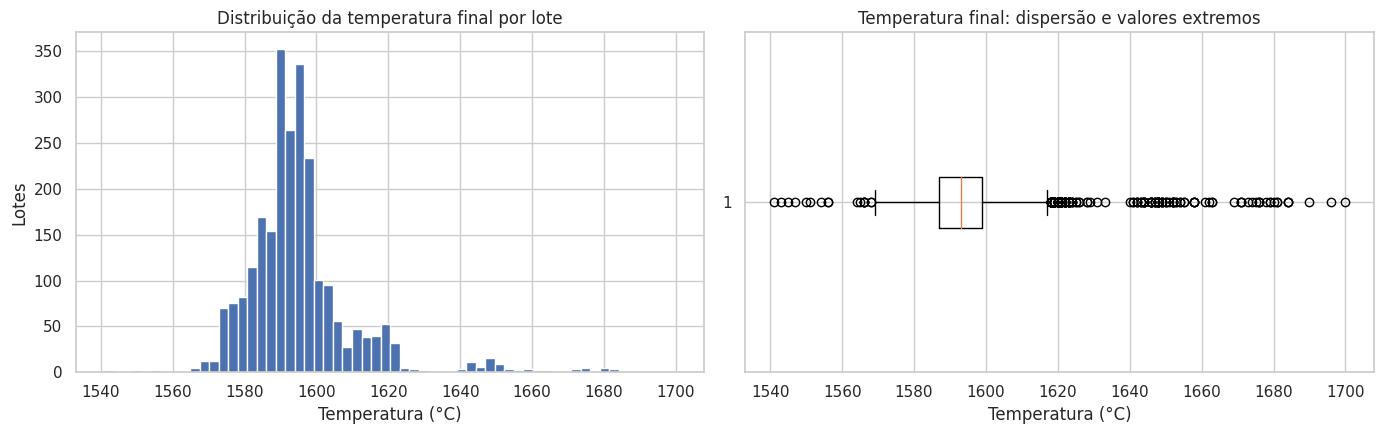

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].hist(perfil_multi['temp_final'], bins=60, color='#4c72b0', edgecolor='white')
axes[0].set_title('Distribuição da temperatura final por lote')
axes[0].set_xlabel('Temperatura (°C)')
axes[0].set_ylabel('Lotes')

axes[1].boxplot(perfil_multi['temp_final'], vert=False)
axes[1].set_title('Temperatura final: dispersão e valores extremos')
axes[1].set_xlabel('Temperatura (°C)')

plt.tight_layout()
plt.show()

A distribuição é concentrada em uma faixa estreita, coerente com um processo industrial controlado. O desvio padrão pequeno diante da média confirma que a temperatura de saída é mantida sob controle apertado, o que ao mesmo tempo torna a previsão mais difícil, já que sobra pouca variância para o modelo explicar.

Há valores atípicos nas duas caudas, com alguns lotes afastados do corpo central da distribuição. A remoção desses pontos será avaliada na Etapa 2 pelo efeito medido sobre o erro, e não por regra fixa, já que eles podem representar condições reais de operação.

O contraste com o conjunto completo é informativo. Considerando todos os lotes, inclusive os de medição única, a temperatura mínima cai para 1204 °C, muito abaixo do mínimo deste recorte. A célula seguinte identifica a origem desse valor.

In [15]:
print('Lotes com temperatura final abaixo de 1400 °C, conjunto completo:')
display(perfil_temp[perfil_temp['temp_final'] < 1400])

print('Assimetria da temperatura final (lotes com 2 ou mais medições):',
      round(perfil_multi['temp_final'].skew(), 2))
print('Curtose da temperatura final:',
      round(perfil_multi['temp_final'].kurtosis(), 2))

Lotes com temperatura final abaixo de 1400 °C, conjunto completo:


,temp_inicial,temp_final,n_medicoes
key,,,
2561,1204.0,1204.0,1


Assimetria da temperatura final (lotes com 2 ou mais medições): 2.19
Curtose da temperatura final: 8.37


O mínimo de 1204 °C vem de um único lote, com uma só medição, em que a leitura inicial e a final são o mesmo registro. Não é um processo que esfriou: é uma leitura isolada em faixa incompatível com aço líquido em panela. A análise da variação de temperatura, mais adiante nesta mesma seção, mostra que o padrão reaparece em lotes com múltiplas medições.

As medidas de forma merecem atenção. A distribuição tem assimetria positiva acentuada e curtose elevada, ou seja, não é normal: o corpo é estreito e a cauda direita é longa. Isso não impede nenhum dos algoritmos propostos, mas tem duas consequências práticas registradas na seção 3.1. A regressão linear terá resíduos não normais, o que afeta a validade de intervalos de confiança ainda que não invalide a previsão pontual. E a diferença entre MAE e RMSE tende a ser grande, já que a cauda pesa mais no segundo.

Além do nível da temperatura final, interessa saber quanto o tratamento altera a temperatura ao longo do ciclo. Essa variação é o que o aquecimento precisa entregar, e portanto o que o modelo indiretamente prevê.

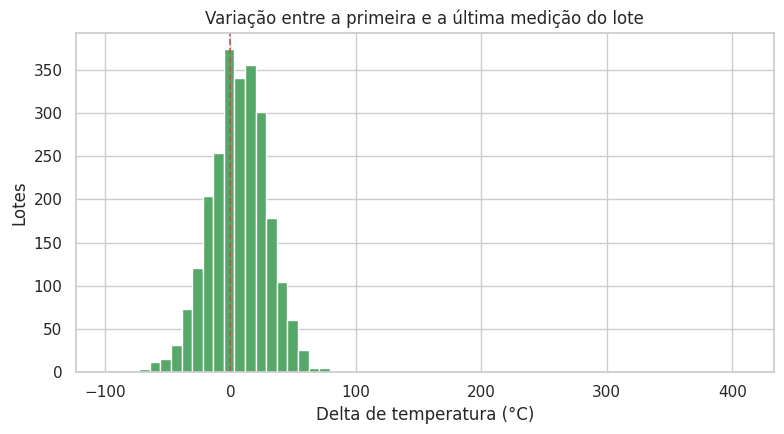

Variação de temperatura ao longo do tratamento:
count    2475.00
mean        6.93
std        27.55
min       -98.00
25%        -8.00
50%         7.00
75%        22.00
max       408.00


In [16]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(perfil_multi['delta_temp'], bins=60, color='#55a868', edgecolor='white')
ax.axvline(0, color='#c44e52', linestyle='--', linewidth=1.2)
ax.set_title('Variação entre a primeira e a última medição do lote')
ax.set_xlabel('Delta de temperatura (°C)')
ax.set_ylabel('Lotes')
plt.tight_layout()
plt.show()

print('Variação de temperatura ao longo do tratamento:')
print(perfil_multi['delta_temp'].describe().round(2).to_string())

A cauda direita do histograma chama atenção. A célula seguinte isola os lotes responsáveis por ela.

In [17]:
extremos = perfil_multi[perfil_multi['delta_temp'].abs() > 100]
print('Lotes com variação de temperatura acima de 100 °C em módulo:', len(extremos))
display(extremos)

Lotes com variação de temperatura acima de 100 °C em módulo: 5


,temp_inicial,temp_final,n_medicoes,delta_temp
key,,,,
867,1191.0,1599.0,6,408.0
1214,1208.0,1591.0,16,383.0
1619,1218.0,1590.0,5,372.0
1817,1591.0,1696.0,8,105.0
2052,1227.0,1592.0,5,365.0


A variação se concentra em torno de valores positivos modestos, com mediana de 7 °C, o que é coerente com um processo de acerto fino e não de aquecimento massivo. A presença de variações negativas mostra que há perda térmica entre medições, provavelmente pela adição de ligas frias e pelo tempo de espera entre operações.

O desvio padrão da variação, porém, é bem maior que o da própria temperatura final, e os extremos explicam o motivo. Cinco lotes apresentam variação superior a 100 °C em módulo, e em quatro deles a temperatura inicial registrada fica em torno de 1200 °C, valor muito abaixo do mínimo observado entre as temperaturas finais deste mesmo recorte.

Uma leitura inicial nessa faixa não é fisicamente compatível com aço líquido em panela pronto para tratamento. O padrão indica falha de leitura da sonda na primeira medição, e não variação real do processo. Esses lotes serão candidatos naturais à remoção na Etapa 2, com a decisão baseada no efeito medido sobre o erro. É o mesmo padrão do lote isolado de 1204 °C identificado antes nesta seção: leituras em torno de 1200 °C que aparecem tanto como medição única quanto como primeira medição de um lote normal.

Um detalhe reforça o diagnóstico. Nesses quatro lotes a temperatura final é normal, entre 1590 °C e 1599 °C. Se o aço estivesse de fato a 1200 °C, o aquecimento necessário para chegar lá seria muito superior ao registrado. A inconsistência está na leitura, não no processo.

### 2.5 Construção da base analítica e preditores candidatos

O problema é definido por lote, mas os dados chegam em nível de evento. Antes de qualquer modelagem será preciso agregar `data_arc_en` e `data_temp_en` por `key` e unir as sete fontes em uma tabela com uma linha por lote.

O bloco a seguir monta uma versão preliminar dessa base, apenas para dimensionar o conjunto final e avaliar quais variáveis se relacionam com o alvo.

In [18]:
arc_lim = arc_dt[arc_dt['Reactive power'] >= 0].copy()
print('Ciclos removidos por potência reativa negativa:', len(arc_dt) - len(arc_lim))
arc_lim['energia'] = arc_lim['Active power'] * arc_lim['duracao_s']

agg_arc = arc_lim.groupby('key').agg(
    pot_ativa_total   = ('Active power',   'sum'),
    pot_reativa_total = ('Reactive power', 'sum'),
    duracao_total_s   = ('duracao_s',      'sum'),
    n_ciclos_arco     = ('Active power',   'count'),
    energia_total     = ('energia',        'sum'),
)

print('Lotes com dados de arco:', len(agg_arc))
agg_arc.describe().round(2)

Ciclos removidos por potência reativa negativa: 1
Lotes com dados de arco: 3214


,pot_ativa_total,pot_reativa_total,duracao_total_s,n_ciclos_arco,energia_total
count,3214.00,3214.00,3214.00,3214.00,3214.00
mean,3.10,2.32,794.55,4.63,713.38
std,1.40,1.05,332.49,1.61,515.88
min,0.19,0.16,57.00,1.00,10.61
25%,2.13,1.60,571.00,4.00,354.60
50%,2.99,2.23,770.00,4.00,605.94
75%,3.90,2.90,983.00,6.00,927.59
max,17.50,12.59,4189.00,16.00,8624.44


A feature `energia_total` é construída como o produto entre a potência ativa e a duração de cada ciclo, somado por lote. Como a unidade original da potência não é informada, o valor funciona como um índice proporcional à energia elétrica aplicada, suficiente para a modelagem ainda que não esteja em unidade física nomeada.

In [19]:
bulk_idx = bulk.set_index('key')
bulk_idx.columns = [f'bulk_{i}' for i in range(1, bulk_idx.shape[1] + 1)]

wire_idx = wire.set_index('key')
wire_idx.columns = [f'wire_{i}' for i in range(1, wire_idx.shape[1] + 1)]

gas_idx = gas.set_index('key')
gas_idx.columns = ['gas']

perfil_base = perfil_multi.drop(columns=['delta_temp'])

base = (perfil_base
        .join(agg_arc, how='inner')
        .join(bulk_idx, how='left')
        .join(wire_idx, how='left')
        .join(gas_idx,  how='left'))

cols_material = [c for c in base.columns if c.startswith(('bulk_', 'wire_'))]
base[cols_material] = base[cols_material].fillna(0)

print('Base analítica preliminar:', base.shape)
print('Valores ausentes restantes:', base.isna().sum().sum())
print('Ausentes na coluna gas:', base['gas'].isna().sum())

base = base.dropna(subset=['gas'])
print('Base após remover lotes sem registro de gás:', base.shape)

sem_variancia = [c for c in base.columns if base[c].nunique() <= 2 and (base[c] != 0).sum() <= 1]
print('\nColunas descartadas por variância praticamente nula:', sem_variancia)

base = base.drop(columns=sem_variancia)
print('Base analítica final:', base.shape)
print(f'Preditores candidatos: {base.shape[1] - 1}')

Base analítica preliminar: (2475, 33)
Valores ausentes restantes: 2
Ausentes na coluna gas: 2
Base após remover lotes sem registro de gás: (2473, 33)

Colunas descartadas por variância praticamente nula: ['bulk_8', 'wire_5']
Base analítica final: (2473, 31)
Preditores candidatos: 30


A base reúne os lotes que têm simultaneamente histórico de temperatura com pelo menos duas medições e registro de aquecimento. Dois lotes sem registro de purga de gás foram descartados na sequência.

Em seguida saem as colunas de uso pontual identificadas na seção 2.3, aquelas com uma única observação em todo o período. O descarte é necessário além da questão de utilidade: uma coluna constante tem desvio padrão zero e produz correlação indefinida, o que contaminaria a análise da próxima célula.

Esse é o conjunto sobre o qual o modelo será treinado.

In [20]:
alvo = 'temp_final'
correl = base.select_dtypes('number').corr()[alvo].drop(alvo)
correl = correl.loc[correl.abs().sort_values(ascending=False).index]

print('Correlação com a temperatura final, 15 variáveis mais fortes:')
print(correl.head(15).round(3).to_string())

Correlação com a temperatura final, 15 variáveis mais fortes:
temp_inicial         0.377
energia_total        0.289
pot_ativa_total      0.238
duracao_total_s      0.208
wire_2              -0.205
pot_reativa_total    0.192
bulk_6              -0.174
bulk_12              0.162
wire_4              -0.116
bulk_11             -0.100
wire_7              -0.097
bulk_3              -0.087
bulk_1              -0.084
bulk_7              -0.082
wire_6              -0.070


O mapa de calor a seguir amplia a leitura, mostrando não só a relação de cada preditor com o alvo, mas também as relações entre os próprios preditores.

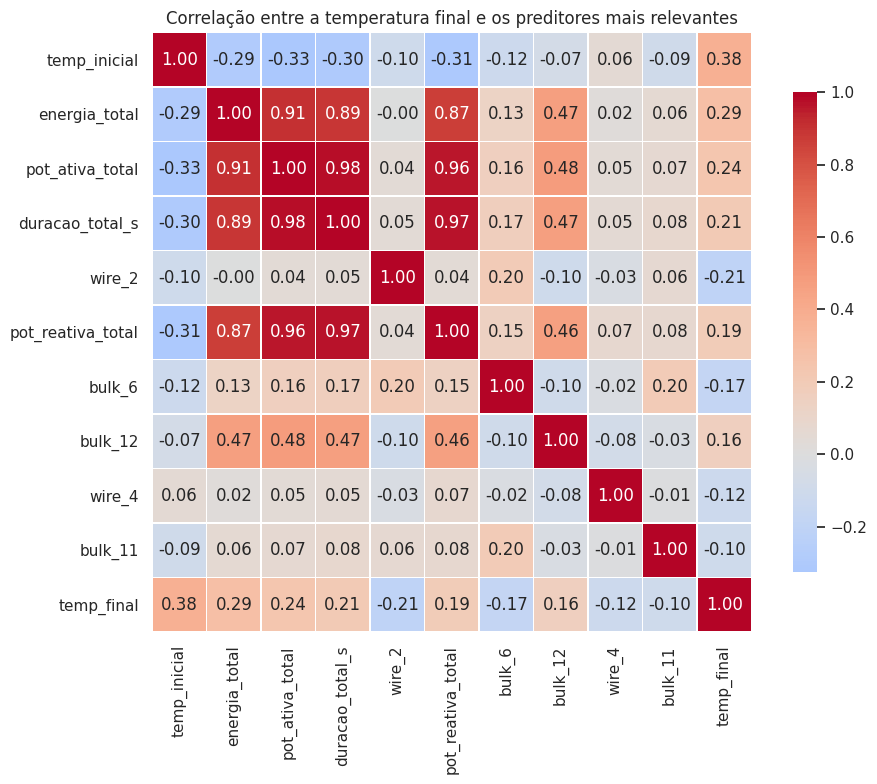

In [21]:
principais = correl.head(10).index.tolist() + [alvo]

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(base[principais].corr(), annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.8}, ax=ax)
ax.set_title('Correlação entre a temperatura final e os preditores mais relevantes')
plt.tight_layout()
plt.show()

Nenhuma variável isolada tem correlação alta com o alvo. Isso é consistente com um processo em que o resultado depende da combinação de vários fatores e não de um único driver dominante. A leitura útil é outra: as variáveis que aparecem no topo são justamente as que fazem sentido físico, ou seja, a temperatura de partida do lote, a energia aplicada, a potência ativa acumulada e o tempo total de arco. Isso indica que há sinal aproveitável e que a construção de features agregadas é o caminho correto.

Uma variável foge desse grupo e merece comentário, justamente por não ser de aquecimento: `wire_2` aparece entre as mais correlacionadas, com sinal negativo. Ela é usada em cerca de um terço dos lotes, e esses lotes terminam em média sete graus mais frios que os demais. A leitura provável é que a coluna marque um tipo de aço cuja especificação de lingotamento é mais baixa, e não que o material esfrie o banho por si só. A pergunta 6 da seção 8 pede a identificação dos materiais justamente para permitir essa distinção, que muda a recomendação operacional.

A ausência de correlação linear forte também reforça a escolha de modelos de ensemble baseados em árvores, capazes de capturar relações não lineares e interações entre aditivos e aquecimento.

O mapa de calor mostra ainda correlação alta entre as próprias variáveis de aquecimento, que derivam umas das outras por construção. Essa multicolinearidade não prejudica os modelos de árvore, mas precisa ser considerada na interpretação dos coeficientes da regressão linear.

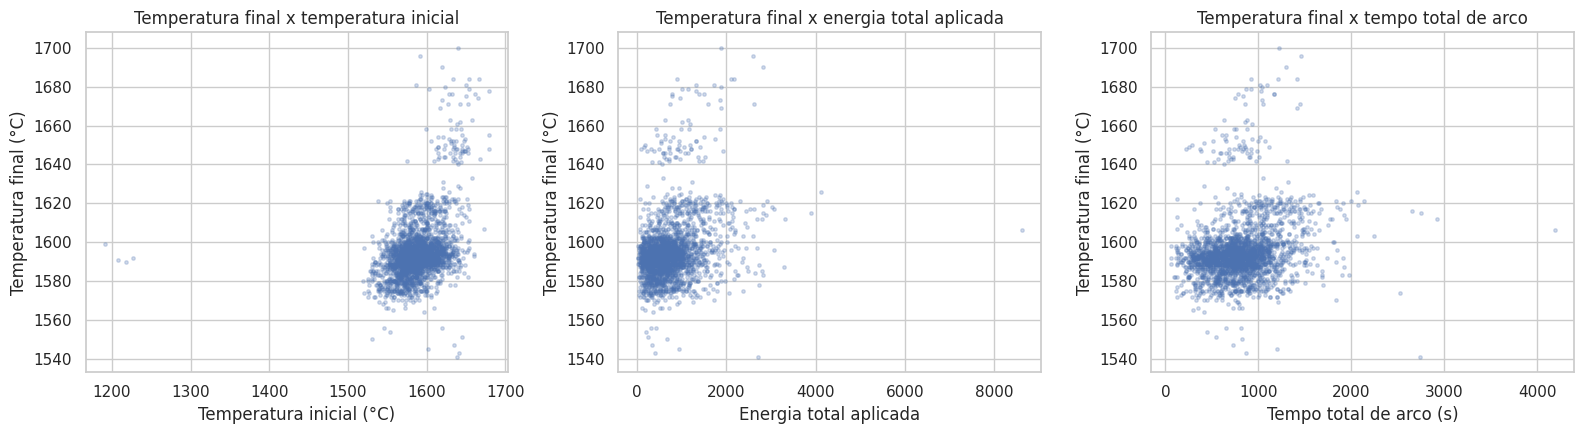

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

pares = [('temp_inicial', 'Temperatura inicial (°C)'),
         ('energia_total', 'Energia total aplicada'),
         ('duracao_total_s', 'Tempo total de arco (s)')]

for ax, (col, rotulo) in zip(axes, pares):
    ax.scatter(base[col], base[alvo], s=6, alpha=0.25, color='#4c72b0')
    ax.set_xlabel(rotulo)
    ax.set_ylabel('Temperatura final (°C)')
    ax.set_title(f'Temperatura final x {rotulo.split("(")[0].strip().lower()}')

plt.tight_layout()
plt.show()

Os gráficos acima cobrem os três preditores mais fortes. A tabela seguinte consolida o comportamento de todas as variáveis da base, encerrando a descrição dos dados.

In [23]:
print('Resumo estatístico dos preditores e do alvo, base analítica final:')
resumo_base = base.describe().T[['count', 'mean', '50%', 'std', 'min', 'max']]
resumo_base.columns = ['n', 'media', 'mediana', 'desvio', 'minimo', 'maximo']
display(resumo_base.round(2))

print('Assimetria das variáveis de aquecimento:')
print(base[['pot_ativa_total', 'pot_reativa_total', 'duracao_total_s',
            'n_ciclos_arco', 'energia_total']].skew().round(2).to_string())

Resumo estatístico dos preditores e do alvo, base analítica final:


,n,media,mediana,desvio,minimo,maximo
temp_inicial,2473.0,1588.40,1588.00,29.25,1191.00,1679.00
temp_final,2473.0,1595.34,1593.00,16.03,1541.00,1700.00
n_medicoes,2473.0,4.96,5.00,1.81,2.00,16.00
pot_ativa_total,2473.0,3.13,3.02,1.43,0.19,17.50
pot_reativa_total,2473.0,2.33,2.23,1.08,0.16,12.59
duracao_total_s,2473.0,799.84,772.00,340.94,57.00,4189.00
n_ciclos_arco,2473.0,4.63,4.00,1.61,1.00,16.00
energia_total,2473.0,722.21,610.34,526.10,10.61,8624.44
bulk_1,2473.0,3.23,0.00,12.07,0.00,185.00
bulk_2,2473.0,1.34,0.00,18.52,0.00,325.00


Assimetria das variáveis de aquecimento:
pot_ativa_total      1.24
pot_reativa_total    1.45
duracao_total_s      1.22
n_ciclos_arco        0.88
energia_total        2.79


O resumo consolida médias, medianas, dispersão e amplitude de todas as variáveis que entram na modelagem. Três leituras se destacam.

As variáveis de aquecimento têm todas assimetria positiva, com cauda direita longa. O caso mais forte é `energia_total`, cuja média fica acima da mediana e cujo máximo supera em mais de dez vezes o valor central. Isso é coerente com a operação: a maioria dos lotes segue um padrão regular e uma minoria exige aquecimento muito prolongado. Esses lotes difíceis são justamente os que mais interessam ao negócio, já que concentram o desperdício de energia que o projeto quer reduzir. A implicação prática é que a transformação logarítmica dessas variáveis será testada na Etapa 2 para o modelo linear, enquanto os modelos de árvore dispensam esse ajuste por serem invariantes a transformações monotônicas dos atributos.

As colunas de material apresentam mediana zero na maioria dos casos, com média puxada pelos poucos lotes que usam cada aditivo. Isso confirma a natureza esparsa dessas features e reforça a escolha de modelos baseados em árvores, que particionam bem esse tipo de variável.

O mínimo de `temp_inicial` permanece em torno de 1200 °C, o que confirma que os lotes com leitura suspeita seguem na base. A remoção fica para a Etapa 2, conforme o critério da seção 5.6, para que o efeito sobre o erro seja medido em vez de presumido.

### 2.6 Validade temporal dos preditores acumulados

A base construída na seção anterior está tecnicamente correta, mas há uma questão que precisa ficar explícita antes de definir os algoritmos, porque ela determina quais colunas podem de fato ser usadas.

Todas as features de aquecimento são somas sobre o lote inteiro, e o mesmo vale para o número de medições. Seus valores totais só existem quando o tratamento termina. A célula a seguir mede o quanto esse acúmulo é sistemático.

In [24]:
acumuladas = ['pot_ativa_total', 'pot_reativa_total', 'duracao_total_s',
               'n_ciclos_arco', 'energia_total']

print('Correlação entre as features acumuladas e o número de medições do lote:')
print(base[acumuladas].corrwith(base['n_medicoes']).round(3).to_string())

print('\nDuração do tratamento por faixa de número de medições:')
faixa = pd.cut(base['n_medicoes'], bins=[1, 3, 5, 7, 16],
               labels=['2 a 3', '4 a 5', '6 a 7', '8 ou mais'])
print(base.groupby(faixa)[['duracao_total_s', 'energia_total']].mean().round(1).to_string())

Correlação entre as features acumuladas e o número de medições do lote:
pot_ativa_total      0.351
pot_reativa_total    0.359
duracao_total_s      0.388
n_ciclos_arco        0.491
energia_total        0.258

Duração do tratamento por faixa de número de medições:
            duracao_total_s  energia_total
n_medicoes                                
2 a 3                 627.3          575.3
4 a 5                 782.3          702.7
6 a 7                 889.7          782.6
8 ou mais            1080.9         1034.1


Os números confirmam a suspeita. Todas as features acumuladas crescem junto com o número de medições, e a duração e a energia aumentam de forma sistemática entre as faixas. Isso é esperado do ponto de vista operacional, já que lotes difíceis exigem mais ciclos, mais tempo e mais medições. O problema é de ordem temporal, não estatística.

Um lote que consumiu 1.500 segundos de arco só revela esse total quando o tratamento acaba. Se o modelo for consumido antes do último aquecimento, esse valor não existe ainda, e usá-lo no treinamento produziria um desempenho de laboratório que não se reproduz na operação.

Há duas leituras possíveis, e a escolha entre elas é uma decisão de negócio e não técnica:

Se a previsão for feita ao final do tratamento, para conferência ou registro, todas as features acumuladas são legítimas e o conjunto atual está correto.

Se a previsão for feita antes ou durante o tratamento, para orientar quanto aquecer, as features precisam ser recortadas no instante da decisão: energia aplicada até ali, ciclos já executados, medições já realizadas. O modelo passaria a prever a temperatura que o lote atingirá, e não a que já atingiu.

A segunda leitura é a que gera o valor descrito na seção 1.3, e por isso é a hipótese de trabalho adotada. A pergunta 5 da seção 8 confirma essa premissa com o líder de equipe antes que a Etapa 2 comece, porque a resposta define a construção de toda a base de features. O plano prevê a construção no formato recortado, com as agregações calculadas por janela até a penúltima medição, e o formato acumulado mantido apenas como referência de comparação.

Definido o instante de corte, cabe a pergunta inversa: o que passa a estar disponível e ainda não foi aproveitado. A base atual usa apenas a primeira temperatura do lote, mas o operador que decide o último aquecimento conhece todas as medições anteriores, e a mais recente delas é a informação mais próxima do estado atual do banho.

In [25]:
temp_pen = temp_v.groupby('key')['Temperature'].apply(
    lambda x: x.iloc[-2] if len(x) >= 2 else np.nan)

comp = perfil_multi[['temp_inicial', 'temp_final']].copy()
comp['temp_penultima'] = temp_pen

print('Poder preditivo de cada medição de temperatura disponível na decisão:')
print(f"  correlação com o alvo, primeira medição  : {comp['temp_inicial'].corr(comp['temp_final']):.3f}")
print(f"  correlação com o alvo, penúltima medição : {comp['temp_penultima'].corr(comp['temp_final']):.3f}")
print()
print(f"  MAE repetindo a primeira medição  : {(comp['temp_final'] - comp['temp_inicial']).abs().mean():.2f} °C")
print(f"  MAE repetindo a penúltima medição : {(comp['temp_final'] - comp['temp_penultima']).abs().mean():.2f} °C")
print()
print('Variação entre a penúltima e a última medição:')
print((comp['temp_final'] - comp['temp_penultima']).describe().round(2).to_string())

Poder preditivo de cada medição de temperatura disponível na decisão:
  correlação com o alvo, primeira medição  : 0.377
  correlação com o alvo, penúltima medição : 0.913

  MAE repetindo a primeira medição  : 19.56 °C
  MAE repetindo a penúltima medição : 5.26 °C

Variação entre a penúltima e a última medição:
count    2475.00
mean        2.55
std         6.79
min       -31.00
25%        -2.00
50%         2.00
75%         6.00
max        34.00


O resultado muda o desenho do projeto e precisa ser registrado com clareza.

A penúltima medição tem correlação muito alta com o alvo, contra a correlação modesta da primeira. Repetir simplesmente o último valor medido, sem modelo algum, já produz erro em torno de cinco graus, melhor que o baseline da média calculado na seção 4.3.

Há duas consequências.

A primeira é que essa variável precisa entrar na base recortada. Ela não é vazamento: sob a hipótese de trabalho adotada, é exatamente o que o operador tem na mão quando decide o último aquecimento. Excluí-la seria descartar a melhor informação disponível.

A segunda é que o baseline correto depende do cenário de uso, e o limiar de erro também. Se a previsão ocorre entre iterações, a régua não é a média histórica, e sim a regra ingênua de repetir a última leitura. Um modelo que não superar cinco graus nesse cenário não justifica sua existência. A seção 4.3 incorpora essa distinção.

### 2.7 Variável-alvo e preditores: resumo

A variável-alvo é `temp_final`, a última medição de temperatura de cada lote, em graus Celsius. Trata-se de variável contínua, o que define o problema como de regressão.

Os preditores candidatos se organizam em quatro grupos:

Estado térmico do lote, com a primeira temperatura medida, a última medição disponível antes da decisão e o número de medições já realizadas. A última medição disponível é o preditor mais forte identificado na seção 2.6. O número de medições está sujeito à ressalva temporal da mesma seção.

Aquecimento, com a potência ativa acumulada, a potência reativa acumulada, o tempo total de arco, o número de ciclos e o índice de energia total. Todo esse grupo é acumulado e depende do recorte temporal discutido na seção 2.6.

Adições químicas, com os volumes de material a granel e de arame por tipo.

Homogeneização, com o volume de gás inerte utilizado na purga.

Os arquivos `data_bulk_time_en` e `data_wire_time_en` não entram diretamente como volume, mas permitem derivar features temporais na Etapa 2, como o intervalo entre a última adição de liga e a medição final, que tem relação direta com a perda térmica observada.

---
## 3. Hipóteses de modelagem

O alvo é contínuo, portanto o problema é de regressão. A base final tem 2.473 lotes e 31 colunas, sendo a variável-alvo e 30 preditores candidatos, todos numéricos após a agregação, sem variáveis categóricas de alta cardinalidade. Essa contagem vale para a versão acumulada; a versão recortada da seção 2.6 terá o mesmo número de colunas, com as agregações calculadas sobre uma janela menor. Esse formato favorece modelos tabulares clássicos e ensembles baseados em árvores.

Os quatro algoritmos abaixo foram escolhidos por atenderem ao tipo de problema, serem implementáveis com os dados disponíveis e admitirem validação por métricas objetivas de erro.

### 3.1 Regressão Linear

Serve como referência interpretável. A física do processo sustenta uma relação aproximadamente proporcional entre energia aplicada e ganho de temperatura, então um modelo linear deve capturar parte do sinal. Sua função aqui é dupla: estabelecer um piso de desempenho e validar se as features agregadas foram bem construídas. Um resultado linear muito ruim indicaria erro na construção das features antes de indicar limitação do algoritmo.

Pressupostos a verificar, todos já identificados na análise exploratória:

Multicolinearidade entre as variáveis de aquecimento, que derivam umas das outras por construção. Ela compromete a interpretação dos coeficientes individuais ainda que não invalide a previsão, e será medida pelo fator de inflação da variância.

Assimetria do alvo e dos preditores de energia, documentada nas seções 2.4 e 2.5. Resíduos não normais não invalidam a estimativa pontual, mas afetam intervalos de confiança e testes de significância. A transformação logarítmica dos preditores de cauda longa será testada como alternativa.

Escalonamento das variáveis numéricas, tratado na seção 5.4.

### 3.2 Random Forest Regressor

Ensemble por bagging, adequado ao volume de dados disponível. Como cada árvore particiona o espaço em vez de ajustar uma função global, o modelo tolera bem valores extremos nos atributos e a esparsidade das colunas de material, além de dispensar escalonamento. Captura interações entre adição de liga e aquecimento sem exigir especificação explícita dessas interações.

Cabe uma ressalva: a robustez vale para os atributos, não para o alvo. O critério de divisão baseado em erro quadrático continua sensível a valores extremos na temperatura, o que reforça a necessidade do tratamento previsto na seção 5.6.

Justificativa no contexto: o processo tem regimes distintos conforme o tipo de aço e a quantidade de liga adicionada, e um modelo baseado em partições lida melhor com esse comportamento por faixas do que um modelo global linear.

### 3.3 LightGBM Regressor

Ensemble por boosting com crescimento de árvore por folha (leaf-wise). Costuma apresentar o melhor desempenho em dados tabulares desse porte e permite controle fino do equilíbrio entre viés e variância por meio da taxa de aprendizado, do número de folhas e dos termos de regularização. Treina rápido, o que viabiliza busca de hiperparâmetros mais ampla dentro do prazo do projeto.

Justificativa no contexto: é o candidato natural a modelo final, pela combinação de desempenho e custo computacional baixo.

### 3.4 CatBoost Regressor

Boosting com o esquema de boosting ordenado (ordered boosting), no qual as estatísticas de cada iteração são calculadas apenas com exemplos anteriores em uma permutação aleatória dos dados. Esse desenho reduz o vazamento interno de alvo típico do gradient boosting tradicional e diminui o risco de sobreajuste. Funciona bem com configuração padrão, o que fornece um ponto de comparação honesto contra o LightGBM otimizado.

Justificativa no contexto: com 2.473 lotes, o sobreajuste é um risco concreto em modelos de boosting, e a regularização embutida do CatBoost oferece proteção adicional.

### 3.5 Referência de comparação

Todos os modelos serão comparados contra um `DummyRegressor` que prevê sempre a média do conjunto de treino. Esse baseline define o ganho mínimo que qualquer modelo precisa superar para justificar sua adoção.

---
## 4. Indicadores-chave (KPIs)

### 4.1 Métrica principal: MAE

O erro absoluto médio é a métrica principal porque se expressa na mesma unidade do alvo, graus Celsius, e conversa diretamente com a tolerância operacional do forno-panela.

$$MAE = \frac{1}{n}\sum_{i=1}^{n} |y_i - \hat{y}_i|$$

### 4.2 Métricas de apoio

RMSE, que penaliza mais os erros grandes. No contexto do caso, um erro de dez graus custa muito mais que dois erros de cinco, porque só o primeiro tende a provocar um ciclo adicional de aquecimento.

$$RMSE = \sqrt{\frac{1}{n}\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}$$

Coeficiente de determinação, para medir a fração da variância da temperatura explicada pelo modelo.

$$R^2 = 1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2}$$

### 4.3 Limiar mínimo aceitável

O limiar precisa ser ancorado no comportamento observado dos dados. A célula abaixo calcula o erro de duas referências triviais.

In [26]:
media_base = base[alvo].mean()

mae_media = (base[alvo] - media_base).abs().mean()
mae_inicial = (base[alvo] - base['temp_inicial']).abs().mean()

print(f'Recorte usado nesta seção: {len(base)} lotes (base analítica final)')
print(f'Desvio padrão da temperatura final : {base[alvo].std():.2f} °C')
print(f'MAE prevendo sempre a média        : {mae_media:.2f} °C')
print(f'MAE prevendo a temperatura inicial : {mae_inicial:.2f} °C')

Recorte usado nesta seção: 2473 lotes (base analítica final)
Desvio padrão da temperatura final : 16.03 °C
MAE prevendo sempre a média        : 10.23 °C
MAE prevendo a temperatura inicial : 19.57 °C


O baseline da média estabelece o patamar a superar: qualquer modelo com erro próximo desse valor não agrega informação ao operador, que já conhece a média histórica. A referência da temperatura inicial tem desempenho pior que a média, o que confirma que o tratamento altera a temperatura de forma relevante. Nenhuma das duas usa features acumuladas, então ambas permanecem válidas qualquer que seja a resposta sobre o recorte temporal da seção 2.6. Na Etapa 2 o baseline será implementado com um DummyRegressor ajustado apenas no treino.

Fixar o limiar em 6,0 °C, cerca de 40% abaixo do baseline, pressuporia que a média histórica é a régua correta. A seção 2.6 mostrou que nem sempre é, e por isso o limiar precisa ser definido por cenário de uso.

Cenário A, previsão antes do primeiro aquecimento. O operador conhece a temperatura de chegada, a composição planejada e o gás previsto, mas nada sobre o aquecimento, que ainda não ocorreu. A referência é o baseline da média, com erro de 10,23 °C. A única variável térmica disponível é a temperatura inicial, com correlação de 0,377 contra o alvo, e as adições químicas ficam abaixo de 0,21 em módulo, de modo que a redução possível é modesta. Limiar: MAE abaixo de 8,0 °C, redução de aproximadamente 22%, com R² acima de 0,50.

Cenário B, previsão entre iterações, que é a hipótese de trabalho adotada. O operador conhece todas as medições anteriores e a energia já aplicada, e a penúltima medição tem correlação de 0,913 com o alvo. A referência deixa de ser a média e passa a ser a regra ingênua de repetir a última leitura, com erro de 5,26 °C, diante da qual um limiar de 6,0 °C seria pior que não ter modelo. Limiar: MAE abaixo de 4,5 °C, redução de aproximadamente 15% sobre a regra ingênua, com R² acima de 0,80.

Em ambos os cenários vale o critério de generalização: diferença entre o erro de treino e o de teste inferior a 15%. A distinção entre os cenários é o que impede o erro mais comum neste tipo de projeto, que é reportar um MAE aparentemente bom mas que perde para uma regra trivial. A pergunta 5 da seção 8 define qual cenário vale.

Os limiares foram derivados dos dados e não de uma especificação da planta. A pergunta 2 da seção 8 leva o ponto para a engenharia de processo, já que a tolerância real do lingotamento pode ser mais ou menos exigente que os valores propostos.

---
## 5. Desenho experimental

### 5.1 Particionamento

Divisão em treino e teste na proporção de 75% e 25%, com semente fixa para garantir reprodutibilidade. A divisão será estratificada por faixa de temperatura, usando os quartis do alvo como estratos, pelo motivo exposto na seção 5.5. O conjunto de teste será reservado desde o início e usado uma única vez, na avaliação final do modelo escolhido.

### 5.2 Validação cruzada

Validação cruzada em cinco partições (folds) dentro do conjunto de treino para toda a seleção de modelos e ajuste de hiperparâmetros. Isso evita que a escolha do modelo dependa de uma divisão específica dos dados e produz estimativa de erro com intervalo de variação, e não apenas um número isolado.

### 5.3 Ajuste de hiperparâmetros

Para Random Forest, LightGBM e CatBoost será usada busca aleatória com `RandomizedSearchCV`, mais eficiente que a busca exaustiva quando o espaço de parâmetros é amplo e o prazo é curto.

Espaços de busca previstos:

Random Forest: número de estimadores, profundidade máxima, mínimo de amostras por divisão e número máximo de features por divisão.

LightGBM: taxa de aprendizado, número de folhas, número de estimadores, fração de amostragem e termos de regularização L1 e L2.

CatBoost: profundidade, taxa de aprendizado, número de iterações e coeficiente de regularização L2.

### 5.4 Escalonamento e vazamento de dados

A regressão linear exige escalonamento das variáveis numéricas com `StandardScaler`. O escalonador será encapsulado em um `Pipeline` do scikit-learn, de modo que, durante a validação cruzada, o ajuste ocorra apenas nas partições de treino de cada fold, e nunca sobre os dados usados na avaliação. Os modelos de árvore dispensam essa etapa.

Há um segundo risco de vazamento, tratado em detalhe na seção 2.6 e retomado aqui pelo efeito que tem sobre o desenho. Nenhuma feature pode conter informação posterior ao instante da previsão. O critério é temporal e não estatístico, o que produz duas conclusões de sinais opostos.

As somas de energia, tempo e ciclos só se completam ao final do tratamento e por isso precisam ser recortadas. Já a penúltima medição de temperatura, apesar de ter correlação muito alta com o alvo, é anterior ao instante da decisão e portanto legítima. Correlação alta não é sinônimo de vazamento: o que importa é se a informação existe quando a previsão é feita.

A consequência prática para o experimento é que a base será construída em duas versões. A versão recortada, com as agregações limitadas ao instante da decisão, é a que sustenta a aplicação descrita na seção 1.3 e será a base oficial de avaliação. A versão acumulada será treinada em paralelo apenas como teto de referência: a diferença de MAE entre as duas quantifica quanto do desempenho vinha de informação indisponível na operação. Um modelo recortado com erro próximo do acumulado indica que as features de estado inicial carregam o sinal; uma distância grande indica que o ganho aparente dependia de vazamento.

A pergunta 5 da seção 8 confirma qual das duas versões corresponde ao uso pretendido.

### 5.5 Balanceamento e o que o substitui neste caso

O balanceamento de classes não se aplica aqui, porque o alvo é contínuo e não há classes a equilibrar. O problema análogo em regressão é o desequilíbrio da distribuição do alvo: como a temperatura final se concentra em uma faixa estreita com cauda direita longa, o modelo tende a acertar bem o centro e errar mais nos lotes atípicos, que são exatamente os de maior interesse operacional.

Três medidas endereçam esse ponto no lugar do balanceamento:

Estratificação da partição por faixa de temperatura, dividindo o alvo em quartis e garantindo que treino e teste tenham representação equivalente das caudas.

Avaliação do erro segmentada por faixa de temperatura, e não apenas do MAE global, para expor um eventual desempenho ruim nos extremos que a média esconderia.

Comparação entre MAE e RMSE. Uma diferença grande entre as duas métricas sinaliza que o erro está concentrado em poucos lotes de cauda, o que muda a recomendação operacional.

### 5.6 Tratamento de valores extremos

Remoção do registro anômalo de potência reativa antes da agregação. Avaliação dos lotes com temperatura final afastada do corpo central da distribuição, testando o efeito da remoção sobre o MAE. A decisão será tomada por comparação de resultado e não por regra arbitrária.

### 5.7 Análise de importância

Ao final, extração da importância das features do melhor modelo e verificação de coerência com a física do processo. Um modelo que apoia sua previsão em energia aplicada e temperatura de partida é defensável perante a engenharia. Um modelo que se apoia em variáveis sem relação causal com temperatura seria sinal de problema na construção da base, mesmo com bom MAE.

### 5.8 Como o desenho sustenta os limiares

A validação cruzada reduz o risco de superestimar o desempenho por acaso da partição. O ajuste de hiperparâmetros extrai o melhor de cada família de modelos antes da comparação. O tratamento de extremos evita que poucos lotes atípicos dominem o erro médio. A construção cuidadosa das features térmicas é o principal fator de ganho. No Cenário B, a inclusão da última medição disponível é o que separa um erro em torno de quatro graus de um erro em torno de seis.

O recorte temporal age no sentido oposto, e isso é deliberado. Ao remover informação posterior ao instante da decisão, ele reduz o desempenho medido em relação à versão acumulada. O objetivo do desenho não é maximizar o número reportado, e sim garantir que o número reportado se reproduza na planta.


## 6. Ações a executar

O projeto tem duas semanas, de 25 de agosto a 7 de setembro, o que corresponde a dez dias úteis. Os cinco primeiros foram consumidos pela Etapa 1, entre o entendimento do caso, o diagnóstico dos dados e a análise exploratória deste notebook. Restam cinco dias úteis para as Etapas 2 e 3, e o plano abaixo se ajusta a esse prazo.

| Grupo | Atividade | Horas |
|---|---|---|
| Limpeza | Remover medições de `Temperature` sem leitura registrada | 1 |
| Limpeza | Remover o registro de potência reativa fora de faixa física | 1 |
| Limpeza | Converter colunas de horário e validar consistência dos ciclos | 2 |
| Limpeza | Aplicar o critério de elegibilidade dos lotes | 1 |
| Limpeza | Avaliar remoção dos lotes com leitura suspeita de temperatura | 2 |
| Preparação | Agregar `data_arc_en` por lote nas versões recortada e acumulada | 4 |
| Preparação | Agregar `data_temp_en`, incluindo a última medição anterior à decisão | 3 |
| Preparação | Substituir por zero os ausentes de material e descartar colunas sem variância | 1 |
| Preparação | Derivar features temporais de `bulk_time` e `wire_time` | 3 |
| Preparação | Unir as sete fontes pela chave `key` | 2 |
| Preparação | Particionar em treino e teste com `Pipeline` de escalonamento | 2 |
| Modelagem | Implementar os baselines de referência | 1 |
| Modelagem | Treinar os quatro algoritmos em configuração padrão | 4 |
| Modelagem | Otimizar hiperparâmetros dos dois melhores | 6 |
| Modelagem | Avaliar no teste e verificar os limiares da seção 4.3 | 2 |
| Comunicação | Gráficos de diagnóstico e importância das features | 3 |
| Comunicação | Relatório de solução com resultados e limitações | 4 |
| Comunicação | Traduzir o erro em impacto sobre energia e tempo de panela | 2 |

Total de 44 horas em cinco dias úteis, o que exige ritmo acima do usual mas é viável porque as decisões de maior peso já foram tomadas nesta etapa. O critério de junção, o tratamento dos ausentes, o recorte temporal das features e os limiares por cenário estão definidos, então a Etapa 2 é execução e não investigação.

Se o prazo apertar, a otimização de hiperparâmetros é a atividade elástica: reduzir o espaço de busca libera de 2 a 3 horas sem comprometer a comparação entre os modelos.

---
## 7. Stakeholders impactados

Gerência de produção da aciaria. Responde pelo ritmo e pela sequência dos lotes. A redução do tempo médio de panela aumenta a vazão da área, que é o indicador central dessa gerência.

Engenharia de processo e metalurgia. Precisa validar se as variáveis usadas pelo modelo fazem sentido físico e traduzir a previsão em procedimento operacional. Sem esse aval, o modelo não chega ao chão de fábrica.

Área de energia e custos. Quantifica a economia obtida e acompanha o consumo específico por tonelada. É o stakeholder que converte o ganho técnico em resultado financeiro reportável.

Manutenção. O consumo de eletrodo de grafite e o desgaste do revestimento refratário da panela dependem do perfil térmico aplicado. A redução de ciclos de aquecimento afeta diretamente o planejamento de reposição desses insumos.

Área de sustentabilidade e meio ambiente. A redução de consumo elétrico se traduz em menor emissão associada, o que alimenta os indicadores ambientais citados no contexto do caso.

Operadores do forno-panela. São os usuários finais de qualquer ferramenta derivada do modelo. A previsão só gera valor se estiver disponível no momento da decisão e em formato utilizável na rotina de operação.

Qualidade. A temperatura de saída afeta a solidificação no lingotamento contínuo e, por consequência, as propriedades da placa produzida. Essa área precisa confirmar que a otimização de energia não compromete a especificação do produto.

---
## 8. Perguntas de esclarecimento

1. A temperatura desejada no lingotamento é fixa ou varia conforme o tipo de aço produzido? Se varia, existe registro dessa especificação por lote que possa ser incorporado ao modelo?

2. Qual desvio de temperatura a operação tolera sem gerar retrabalho ou ciclo adicional de aquecimento? Os limiares de MAE adotados neste plano, de 8,0 °C e 4,5 °C conforme o cenário da seção 4.3, foram derivados da variabilidade observada nos dados e precisam ser confrontados com a tolerância real do processo.

3. Os lotes com uma única medição de temperatura correspondem a interrupção do tratamento ou representam um fluxo válido de produção? A decisão de excluí-los da base depende dessa resposta.

4. Como interpretar o registro isolado de potência reativa negativa em `data_arc_en`: falha de sensor, lançamento de correção ou fenômeno real do processo?

5. Em que momento do ciclo a previsão será consumida: antes do aquecimento, para orientar quanto aplicar, ou ao final do tratamento, para conferência? Esta é a pergunta mais importante da lista. Como mostra a seção 2.6, todas as features de aquecimento são somas sobre o lote inteiro e só existem quando o tratamento termina. Se o uso for anterior ao aquecimento, elas precisam ser recortadas no instante da decisão, o que redefine a base de features e provavelmente o limiar de erro. A hipótese de trabalho adotada é a de uso anterior ao aquecimento, por ser a que gera o valor descrito na seção 1.3, e ela precisa ser confirmada antes que a Etapa 2 comece.

6. Os identificadores `Bulk 1` a `Bulk 15` e `Wire 1` a `Wire 9` correspondem a materiais específicos? Conhecer a natureza de cada um permite interpretar a importância das features e sustentar a recomendação junto à engenharia.

7. As medições de temperatura sem valor registrado têm alguma causa sistemática conhecida, como tipo de sonda ou turno de operação? Se houver padrão, a ausência carrega informação e não deveria ser simplesmente descartada.

8. Existe restrição de tempo de resposta, de infraestrutura ou de integração com o sistema de automação da planta que deva orientar a escolha do modelo final?

---
## 9. Plano geral de resolução

**Passo 1. Limpeza e definição do escopo de dados.** Carregar os sete arquivos, tratar os valores ausentes e o registro anômalo de potência reativa, converter as colunas de horário e definir o conjunto de lotes elegíveis para modelagem.

**Passo 2. Construção da base analítica em duas versões.** Agregar e unir as sete fontes pela chave key, construindo as features de aquecimento em duas versões: recortada no instante da decisão e acumulada como referência.

**Passo 3. Análise exploratória aprofundada.** Investigar distribuições, correlações, valores extremos e a relação entre energia aplicada e ganho de temperatura, selecionando os preditores mais promissores e validando sua coerência física.

**Passo 4. Modelagem e otimização.** Treinar os quatro algoritmos propostos contra o baseline nas duas versões da base, comparar por validação cruzada e ajustar os hiperparâmetros dos dois melhores. A diferença de MAE entre as versões quantifica quanto do desempenho dependia de informação indisponível na operação.

**Passo 5. Avaliação e comunicação.** Avaliar o modelo escolhido no conjunto de teste reservado, analisar resíduos e importância das features, e traduzir o resultado em recomendação operacional para a Steelproof.